# Modeling a Minecraft Skin Classifier
---

## 1. Problem Statement (Business Understanding)

### What are we solving?

Minecraft servers often need to automatically detect skins that violate copyright or community guidelines  
(e.g. skins depicting Spider-Man, other characters, or inappropriate content).
Manual review is not scalable - a Minecraft server can have thousands of players.

**Goal:** Build a binary image classifier that automatically flags a Minecraft skin as:  
- **Class 0 - normal** (generic, community-created skin)  
- **Class 1 - flagged** (depicts a copyrighted / banned character, e.g. Spider-Man)

### Why does recall matter more than precision here?

A **false negative** (flagged skin classified as normal) means a banned skin slips through → real harm.  
A **false positive** (normal skin flagged as bad) means an unfair temporary ban → recoverable harm.  

Therefore we optimize **recall** (sensitivity) while keeping precision acceptable.  
We will tune the classification **threshold** accordingly after training.

### Why CNN?

Minecraft skins are 64×64 RGBA pixel images where **spatial structure is fixed**  
(head always top-left, body always center, etc.).  
CNNs exploit local spatial correlations via shared convolutional filters, making them the natural choice for structured image data. They learn hierarchical features (edges → textures → shapes)
without hand-crafted feature engineering.

Unlike a fully connected network, a CNN uses **weight sharing** and **local receptive fields**,  
which drastically reduces parameters and improves generalization on small datasets.

## Setup & Imports

We use **TensorFlow** for the deep learning pipeline and **scikit-learn** for evaluation metrics.
All random seeds are fixed for reproducibility.

In [106]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import Sequential, layers
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 3. Central Configuration

**Design decision:** All tunable parameters are defined here in one place.  
This makes the notebook easy to re-run with different settings without hunting through code.  
It also documents every hyperparameter choice explicitly.

In [107]:
# data loading
ROOT = Path("./../")
GOOD_DIR = ROOT / "data" / "skins" / "good" # class 0
BAD_DIR = ROOT / "data" / "skins" / "bad" / "spiderman_cleaned" # class 1
MODEL_PATH = ROOT / "04_Modeling" / "best_model.keras"

# image specs
IMG_SIZE = (64, 64)
N_CHANNELS = 4 # RGBA, transparency is important

# data splits
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

# training params
BATCH_SIZE = 32 # small enough for memory, large enough for stable gradients
MAX_EPOCHS = 50 # early stopping will terminate earlier if needed
PATIENCE = 10 # epochs without val_loss improvement before stopping, pretty patient
# learning rate
LR_INIT = 3e-4
LR_FACTOR = 0.5 # halve LR on plateau
LR_PATIENCE = 3 # epochs before LR reduction

# threshold tuning
RECALL_TARGET = 0.90

print(f"Good skins dir: {GOOD_DIR}")
print(f"Bad  skins dir: {BAD_DIR}")
print(f"Image size: {IMG_SIZE}, channels: {N_CHANNELS}")

Good skins dir: ..\data\skins\good
Bad  skins dir: ..\data\skins\bad\spiderman_cleaned
Image size: (64, 64), channels: 4


## Data Loading

We load all `.png` files from `good/` (label 0) and all `.png` files recursively from `bad/` (label 1).  
The `bad/` directory contains one subdirectory per keyword (e.g. `spiderman/`), so we glob recursively.

### Why do we keep the alpha channel?

The Minecraft skin format uses the **alpha channel** as a mask - it encodes which pixels are part of
the skin vs. transparent (unused) regions. Discarding it would lose structural information that could  
help the model distinguish character skins (which often have distinctive transparency patterns).

In [108]:
def find_img_paths(good_dir: Path, bad_dir: Path):
    # Iterate over this subtree and yield all existing files (of any kind, including directories) matching the given relative pattern.
    good_paths = sorted(good_dir.glob("*.png"))[:9000]
    bad_paths  = sorted(bad_dir.rglob("*.png"))[:1000]
    # loading more images would increase training time, tensorflow gpu support didnt work for us out of the box, so we have to limit our data

    paths  = good_paths + bad_paths
    labels = [0] * len(good_paths) + [1] * len(bad_paths)

    print(f"Good skins (class 0): {len(good_paths)}")
    print(f"Bad  skins (class 1): {len(bad_paths)}")
    print(f"Total: {len(paths)}")
    print(f"Class ratio bad/good: {len(bad_paths)/len(good_paths):.3f}")
    return paths, labels

all_paths, all_labels = find_img_paths(GOOD_DIR, BAD_DIR)

Good skins (class 0): 9000
Bad  skins (class 1): 961
Total: 9961
Class ratio bad/good: 0.107


In [109]:
def load_images(paths, img_size=(64, 64)):
    imgs = []
    for p in paths:
        # https://keras.io/api/data_loading/image/
        img = tf.keras.utils.load_img(str(p), color_mode="rgba", target_size=img_size)
        arr = tf.keras.utils.img_to_array(img) / 255.0 # normalize to [0, 1]
        imgs.append(arr)
    return np.array(imgs, dtype=np.float32)

print("Loading images")
X = load_images(all_paths)
y = np.array(all_labels, dtype=np.float32)

print(f"X shape: {X.shape}  →  (samples, height, width, channels)")
print(f"y shape: {y.shape}")
print(f"Pixel value range: [{X.min():.2f}, {X.max():.2f}]")

Loading images
X shape: (9961, 64, 64, 4)  →  (samples, height, width, channels)
y shape: (9961,)
Pixel value range: [0.00, 1.00]


## Exploratory Data Analysis

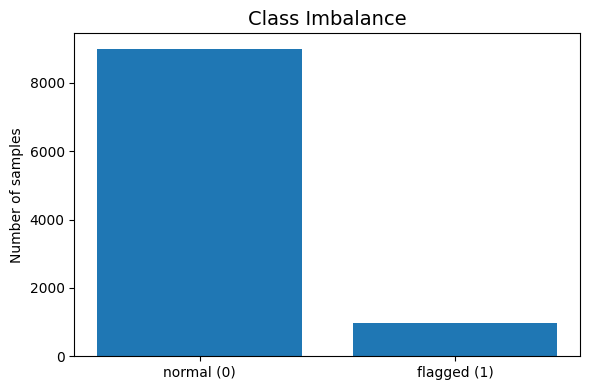

Imbalance ratio (bad/good): 0.11


In [110]:
class_counts = pd.Series(y).value_counts().sort_index()
class_names  = ["normal (0)", "flagged (1)"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_names, class_counts.values)
ax.set_title("Class Imbalance", fontsize=14)
ax.set_ylabel("Number of samples")
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts[1] / class_counts[0]
print(f"Imbalance ratio (bad/good): {imbalance_ratio:.2f}")

Such a ratio needs weighting during training

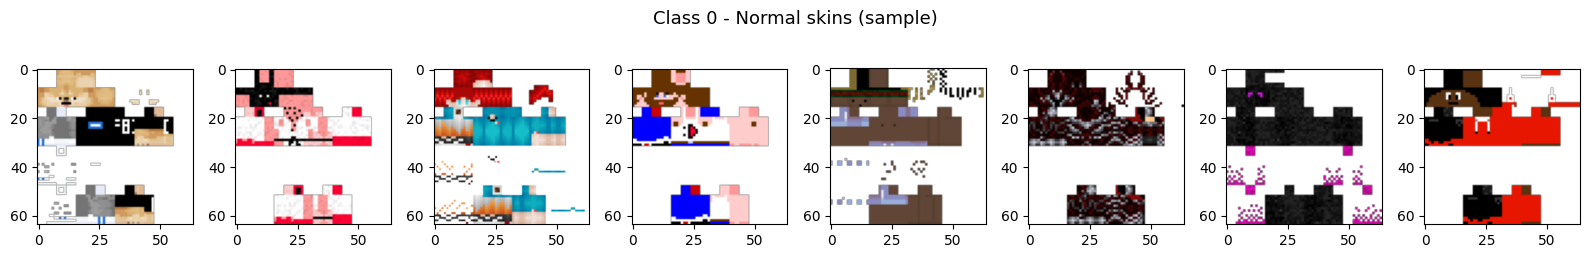

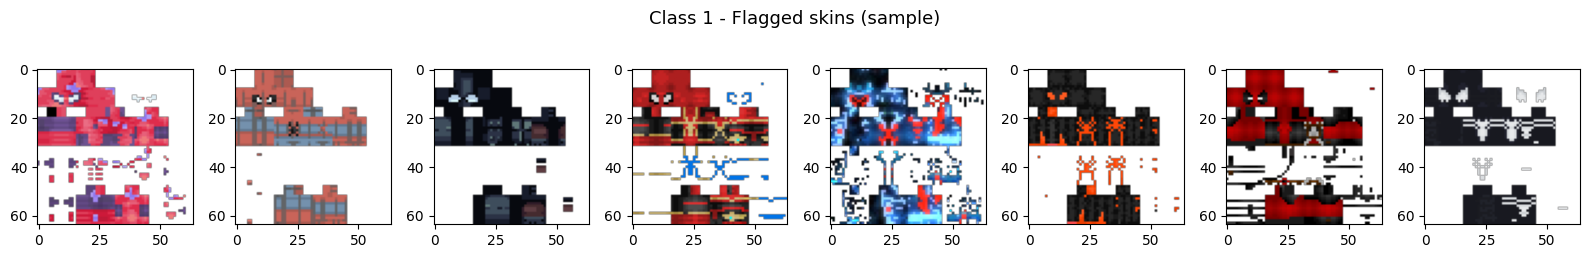

In [111]:
def show_samples(X, y, label, n=8, title=""):
    indices = np.where(y == label)[0]
    chosen  = np.random.choice(indices, size=min(n, len(indices)), replace=False)

    fig, axes = plt.subplots(1, len(chosen), figsize=(2 * len(chosen), 2.5))
    fig.suptitle(title, fontsize=13)
    for ax, idx in zip(axes, chosen):
        ax.imshow(X[idx, :, :, :4])
    plt.tight_layout()
    plt.show()

show_samples(X, y, label=0, n=8, title="Class 0 - Normal skins (sample)")
show_samples(X, y, label=1, n=8, title="Class 1 - Flagged skins (sample)")

A normal looking skin was labeled as spiderman. Apparently the scraped data is not clean enough. We hope that the model can converge and we will check bad false negatives later to swap the labels and re-train

## 6. Train / Validation / Test Split

We use a **stratified** split to ensure the class ratio is preserved in all 3 sets.

In [112]:
# split off test set and preserve it for the end
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=TEST_SPLIT,
    stratify=y, # preserve class ratio
    random_state=SEED
)

# split training into train + validation
val_relative = VAL_SPLIT / (1 - TEST_SPLIT) # should be around 0,176
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_relative,
    stratify=y_trainval,
    random_state=SEED
)

print(f"Train: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass 1 ratio in train: {y_train.mean():.3f}") # we can just take the mean as we only have two classes
print(f"Class 1 ratio in val: {y_val.mean():.3f}")
print(f"Class 1 ratio in test: {y_test.mean():.3f}")

Train: 6,972 samples (70%)
Val: 1,494 samples (15%)
Test: 1,495 samples (15%)

Class 1 ratio in train: 0.097
Class 1 ratio in val: 0.096
Class 1 ratio in test: 0.096


## 7. Handling Class Imbalance

### Problem

If Class 0 has far more samples than Class 1, a naïve model can achieve high accuracy  
simply by predicting Class 0 for every sample. This is called the **majority-class baseline**.

### Solution: Inverse-frequency class weights
https://www.geeksforgeeks.org/deep-learning/how-to-handle-class-imbalance-in-tensorflow/

We compute weights `w_k = total_samples / (n_classes × count_k)` for each class k.
These weights are passed to `model.fit()` so that errors on the minority class  
count proportionally more in the loss function.  

This is equivalent to **oversampling** the minority class in expectation,  
but requires no data duplication.

In [113]:
n_total = len(y_train)
n_good = int((y_train == 0).sum())
n_bad = int((y_train == 1).sum())
n_classes = 2

# inverse-frequency weighting
class_weights = {
    0: n_total / (n_classes * n_good),
    1: n_total / (n_classes * n_bad),
}

print("Class weights:")
print(class_weights)
print(f"misclassifying a flagged skin costs {class_weights[1]/class_weights[0]}x more than misclassifying a normal skin.")

Class weights:
{0: 0.5534211779647563, 1: 5.179791976225855}
misclassifying a flagged skin costs 9.35958395245171x more than misclassifying a normal skin.


## Data Augmentation

Augmentation artificially increases training diversity, which reduces overfitting and improves generalization to unseen skins.

### What NOT to do with Minecraft skins

Standard augmentations like **horizontal flipping**, **rotation**, or **translation** would break the semantic structure of a Minecraft skin.

The skin format has fixed pixel regions (head: top-left area, body: center, etc.). See below

Shifting the image would move, e.g., the head region into the arm region, creating unwanted inputs that confuse the model.


- **Channel shift / hue phase shifting**: the exact color hue is less class-discriminative
  than the pattern shape

Augmentation is **only applie to the training set** and never to val/test,
because validation and test must reflect the real-world data distribution.

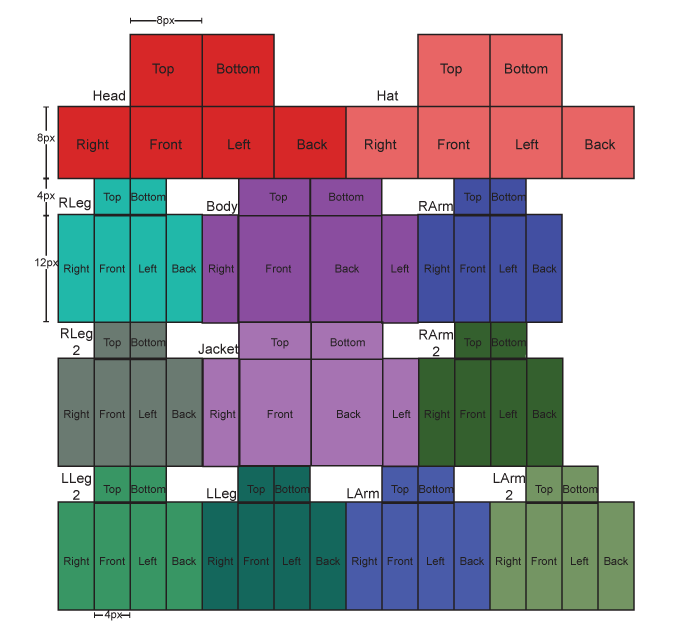

https://www.tensorflow.org/tutorials/images/data_augmentation#data_augmentation_2

In [114]:
import tensorflow as tf
from tensorflow.keras import layers

SHIFT_VAL = 25 / 255 # 10% random color shifts for all images

data_augmentation = tf.keras.Sequential([
    layers.Lambda(lambda x: tf.concat([
        tf.clip_by_value(x[..., :3] + tf.random.uniform(tf.shape(x[..., :3]), -SHIFT_VAL, SHIFT_VAL), 0.0, 1.0),
        # mask the R, G, B Values from x and add random noise to it in the range from SHIFT_VAL, clip it inbetween 0 and 1
        x[..., 3:4] # the alpha value
    ], axis=-1)),
    layers.GaussianNoise(0.1),
])

## Baseline Model

Before training a neural network, we establish a **baseline** the simplest possible model.
This serves as a reference: our CNN must clearly outperform it to justify its complexity.

It is literally based on the class imbalance.
If the model predicts better than a class-weighted random guess, it is better

**Majority class baseline:** predict the most frequent class for every input.
It requires no training but reveals the naive upper bound for accuracy on imbalanced data.

In [115]:
majority_class = np.bincount(y_train.astype(int)).argmax()
baseline_preds = np.full(len(y_test), majority_class) # only class 0 guesses
baseline_acc = (baseline_preds == y_test).mean() # but comparing it with the real labels -> high accuracy
baseline_recall = ((baseline_preds == 1) & (y_test == 1)).sum() / (y_test == 1).sum() # recall is extremly bad!

print(f"Majority class: {majority_class}")
print(f"Accuracy: {baseline_acc}")
print(f"Recall (class 1): {baseline_recall}")

Majority class: 0
Accuracy: 0.9036789297658863
Recall (class 1): 0.0


## CNN

The CNN was adapted from the MNIST CNN example notebook and enhanced for the minecraft skin data

In [116]:
model = Sequential([
        Input(shape=(IMG_SIZE[0], IMG_SIZE[1], N_CHANNELS)),

        data_augmentation,

        # low level patterns
        Conv2D(16, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Conv2D(16, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.4),

        # mid-level patterns
        Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.4),

        # high level patterns
        Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.4),

        GlobalAveragePooling2D(), # reduce parameters
        Dense(64, activation="relu"),
        Dropout(0.6), # prevent overfit
        Dense(1, activation="sigmoid"),
    ], name="minecraft_skin_cnn")

model.summary()

Model: "minecraft_skin_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 64, 64, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 16)     │           592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 77,345 (302.13 KB)

 Trainable params: 76,897 (300.38 KB)

 Non-trainable params: 448 (1.75 KB)

## Model Compilation

### Metrics tracked during training
- **Precision / Recall** - directly measure false-positive and false-negative rates  
- **Accuracy** - kept for comparison with baseline

In [117]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_INIT),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

## Early Stopping and other training callbacks


In [118]:
callbacks = [
    EarlyStopping(
        monitor="val_auc",
        mode="max", # we want to maximize AUC
        patience=PATIENCE,
        restore_best_weights=True, # revert to best epoch after stopping
        verbose=1,
    ),
    ModelCheckpoint( # https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint
        filepath=str(MODEL_PATH),
        monitor="val_auc",
        mode="max", # we want to maximize auc
        save_best_only=True,
        verbose=0,
    ),
]

## Model Training

We pass class weights to every sample to give the minority class proportionally higher loss.
Training will stop automatically when the validation loss stops improving (EarlyStopping).

In [119]:
sample_weights = np.where(y_train == 1, class_weights[1], class_weights[0])
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train, sample_weights))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [120]:
history = model.fit(
    train_dataset,
    epochs=MAX_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

print(f"Training stopped after {len(history.history['loss'])} epochs.")

Epoch 1/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 22s 86ms/step - accuracy: 0.7157 - auc: 0.7963 - loss: 0.5895 - precision: 0.2195 - recall: 0.7608 - val_accuracy: 0.4016 - val_auc: 0.8705 - val_loss: 0.8189 - val_precision: 0.1345 - val_recall: 0.9583
Epoch 2/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.8144 - auc: 0.8836 - loss: 0.4562 - precision: 0.3179 - recall: 0.8053 - val_accuracy: 0.3146 - val_auc: 0.8673 - val_loss: 1.4887 - val_precision: 0.1220 - val_recall: 0.9861
Epoch 3/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 18s 82ms/step - accuracy: 0.8475 - auc: 0.9097 - loss: 0.4024 - precision: 0.3717 - recall: 0.8395 - val_accuracy: 0.7135 - val_auc: 0.9254 - val_loss: 0.6784 - val_precision: 0.2428 - val_recall: 0.9306
Epoch 4/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.8474 - auc: 0.9164 - loss: 0.3892 - precision: 0.3720 - recall: 0.8440 - val_accuracy: 0.6031 - val_auc: 0.9385 - val_loss: 0.9636 - val_precision: 0.1903 - val_recall: 0.9583
Epoch 5/50
218/218 ━━━━━

## Training Curves
We plot loss and key metrics over epochs to assess:
- Whether the model **converged** (curves flatten)
- Whether there is **overfitting** (train improves, val stagnates or worsens)

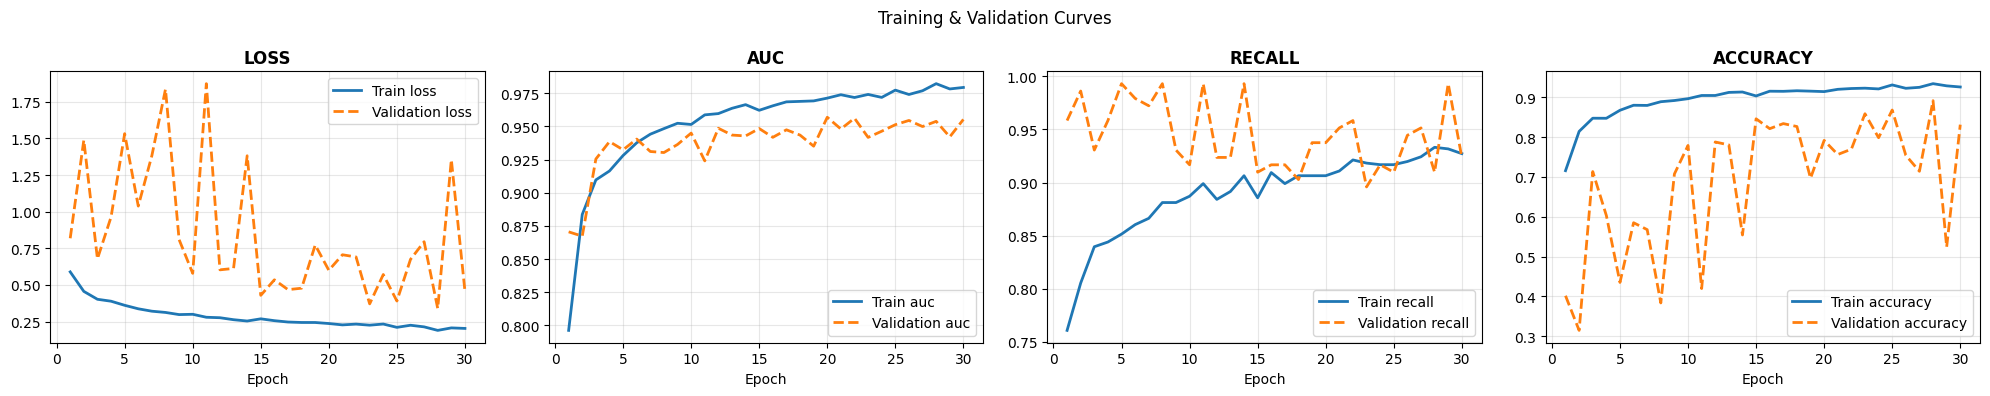

In [121]:
def plot_history(history, metrics=("loss", "auc", "recall", "accuracy")):
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    epochs = range(1, len(history.history["loss"]) + 1)

    for ax, metric in zip(axes, metrics):
        ax.plot(epochs, history.history[metric], label=f"Train {metric}", linewidth=2)
        ax.plot(epochs, history.history[f"val_{metric}"], label=f"Validation {metric}", linewidth=2, linestyle="--")
        ax.set_title(metric.upper(), fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle("Training & Validation Curves")
    plt.tight_layout()
    plt.show()

plot_history(history)

## Evaluation on Test Set

We now evaluate the model on the **test set**. Unseen data.

In [122]:
# Get predicted probabilities
y_prob = model.predict(X_test, verbose=0).ravel()

# Default threshold = 0.5
y_pred_default = (y_prob >= 0.5).astype(int)

auc  = roc_auc_score(y_test, y_prob)
print(f"AUC: {auc}")
print(classification_report(y_test, y_pred_default, target_names=["normal", "spiderman"]))

AUC: 0.9712147380541163
              precision    recall  f1-score   support

      normal       0.99      0.79      0.88      1351
   spiderman       0.33      0.96      0.49       144

    accuracy                           0.81      1495
   macro avg       0.66      0.88      0.69      1495
weighted avg       0.93      0.81      0.85      1495



### Confusion Matrix

The confusion matrix shows the four types of predictions:
- **True Negatives (TN)**: correctly classified as normal  
- **False Positives (FP)**: normal skin wrongly flagged → minor inconvenience  
- **False Negatives (FN)**: flagged skin missed → ⚠️ the error we most want to minimize  
- **True Positives (TP)**: correctly detected flagged skin

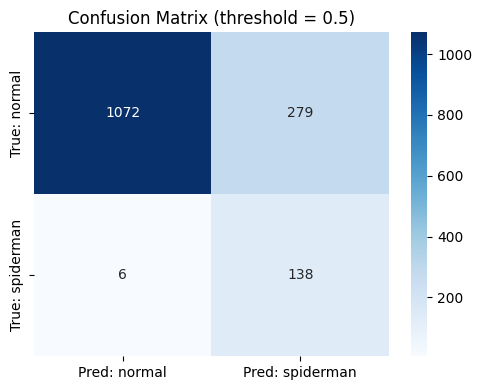

True Negatives (correct normal) : 1072
False Positives (normal→flagged): 279 -> recoverable error
False Negatives (flagged→normal): 6 -> critical error
True Positives (correct flagged): 138


In [123]:
cm = confusion_matrix(y_test, y_pred_default)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: normal", "Pred: spiderman"],
    yticklabels=["True: normal", "True: spiderman"],
    ax=ax
)
ax.set_title("Confusion Matrix (threshold = 0.5)", fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correct normal) : {tn}")
print(f"False Positives (normal→flagged): {fp} -> recoverable error")
print(f"False Negatives (flagged→normal): {fn} -> critical error")
print(f"True Positives (correct flagged): {tp}")

## ROC- and Precision/Recall-Curve

In [124]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

prec, rec, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

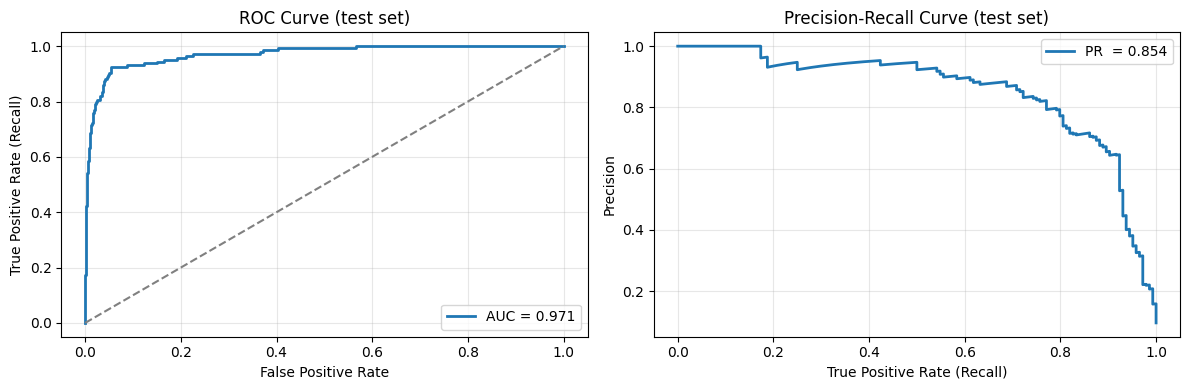

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("ROC Curve (test set)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(rec, prec, linewidth=2, label=f"PR  = {pr_auc:.3f}")
axes[1].set_xlabel("True Positive Rate (Recall)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (test set)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Metrics used
**True Positive Rate (Recall)**: (Recall, Sensitivity)
$$Recall = \text{TPR} = \frac{TP}{TP + FN}$$
> Of all actually flagged spiderman skins, how many did we predict?

**False Positive Rate**:
$$\text{FPR} = \frac{FP}{FP + TN}$$
> Of all actually normal skins, how many did we wrongly flag as spiderman?

**Precision**:
$$\text{Precision} = \frac{TP}{TP + FP}$$
> Of all skins we flagged, how many were truly bad?.

Both curves show classifier behaviour across all thresholds, not just $0.5$.

- ROC plots TPR vs FPR. Standard view, but FPR has $FP + TN$ in the denominator, dominated by the ~9000 normal skins. Many false positives barely shift the curve, so it looks too optimistic!

- PR plots Precision vs Recall, actually the tradeoff we follow with our research question. Precision $\frac{TP}{TP+FP}$ ignores $TN$, so the $9{:}1$ imbalance does not hide errors. Answers what matters here: of all skins we flag, how many are really spiderman?

For our imbalanced, recall-focused problem PR-AUC (Average Precision) is the more meaningful summary than ROC-AUC.

## Threshold Tuning

The default decision threshold of **0.5** is not always optimal, especially when one error type is more costly than the other.

Since we want to **maximise recall** (catch as many flagged skins as possible to reach less false negatives) we sweep all possible thresholds and find the one that maximises F1-score on the **validation set**.
Using the validation set (not test set) for threshold tuning prevents data leakage.

The **Precision-Recall curve** shows the trade-off: lowering the threshold  
increases recall but decreases precision.

In [126]:
# use the validation set (not the test set!) to figure out the max. threshold that allows approx. 95% of recall (5% false negatives) in deployment.
y_prob_val = model.predict(X_val, verbose=0).ravel()

thresholds = np.linspace(0.05, 0.95, 200)
results = []
for t in thresholds:
    y_hat = (y_prob_val >= t).astype(int) # prediction
    rec = ((y_hat == 1) & (y_val == 1)).sum() / max((y_val == 1).sum(), 1)
    pre = ((y_hat == 1) & (y_val == 1)).sum() / max((y_hat == 1).sum(), 1)
    f1  = f1_score(y_val, y_hat, zero_division=0)
    results.append({"threshold": t, "recall": rec, "precision": pre, "f1": f1, })

results_df = pd.DataFrame(results)

# pick the strictest (highest) threshold that still hits the recall target
eligible = results_df[results_df["recall"] >= RECALL_TARGET]
if eligible.empty:
    raise ValueError(f"No threshold reaches recall ≥ {RECALL_TARGET} on the validation set.")
best_row = eligible.loc[eligible["threshold"].idxmax()]
BEST_THRESH = best_row["threshold"]

print(f"Recall target: ≥ {RECALL_TARGET}")
print(f"Chosen threshold: {BEST_THRESH:.4f}")
print(f"Recall: {best_row['recall']:.4f}")
print(f"recision: {best_row['precision']:.4f}")
print(f"F1: {best_row['f1']:.4f}")

Recall target: ≥ 0.9
Chosen threshold: 0.8957
Recall: 0.9028
recision: 0.5078
F1: 0.6500


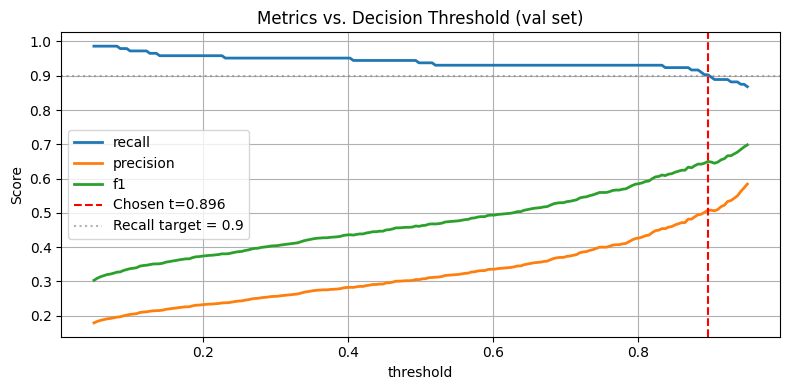

In [127]:
ax = results_df.set_index("threshold")[["recall", "precision", "f1"]].plot(
    figsize=(8, 4), linewidth=2, grid=True
)
ax.axvline(BEST_THRESH, color="red", linestyle="--", label=f"Chosen t={BEST_THRESH:.3f}")
ax.axhline(RECALL_TARGET, color="gray", linestyle=":", alpha=0.6, label=f"Recall target = {RECALL_TARGET}")
ax.set_title("Metrics vs. Decision Threshold (val set)")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

Final Test Evaluation (threshold = 0.8957286432160804)
              precision    recall  f1-score   support

      normal       0.99      0.90      0.94      1351
     flagged       0.50      0.93      0.65       144

    accuracy                           0.90      1495
   macro avg       0.74      0.91      0.80      1495
weighted avg       0.94      0.90      0.91      1495



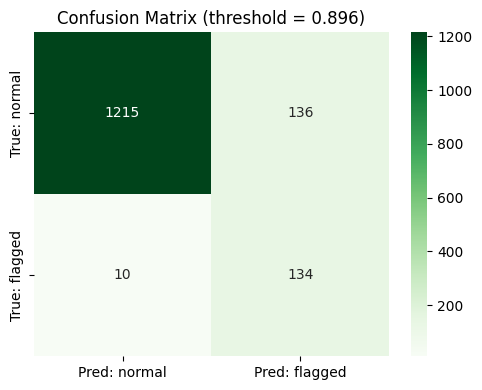

In [128]:
# Final evaluation on TEST set with tuned threshold
y_pred_tuned = (y_prob >= BEST_THRESH).astype(int)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print(f"Final Test Evaluation (threshold = {BEST_THRESH})")
print(classification_report(y_test, y_pred_tuned, target_names=["normal", "flagged"]))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_tuned, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Pred: normal", "Pred: flagged"],
    yticklabels=["True: normal", "True: flagged"],
    ax=ax
)
ax.set_title(f"Confusion Matrix (threshold = {BEST_THRESH:.3f})", fontsize=12)
plt.tight_layout()
plt.show()

## Error Analysis

Visualising the mistakes the model makes helps understand where it struggles and how it could be improved in a next iteration.

# TODO: Print image ids in plots, so we can easily modify our data set

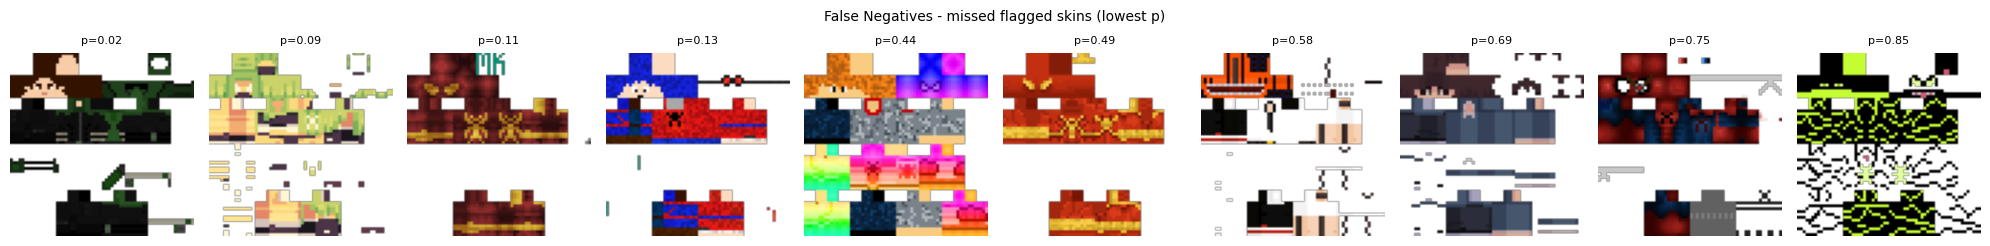

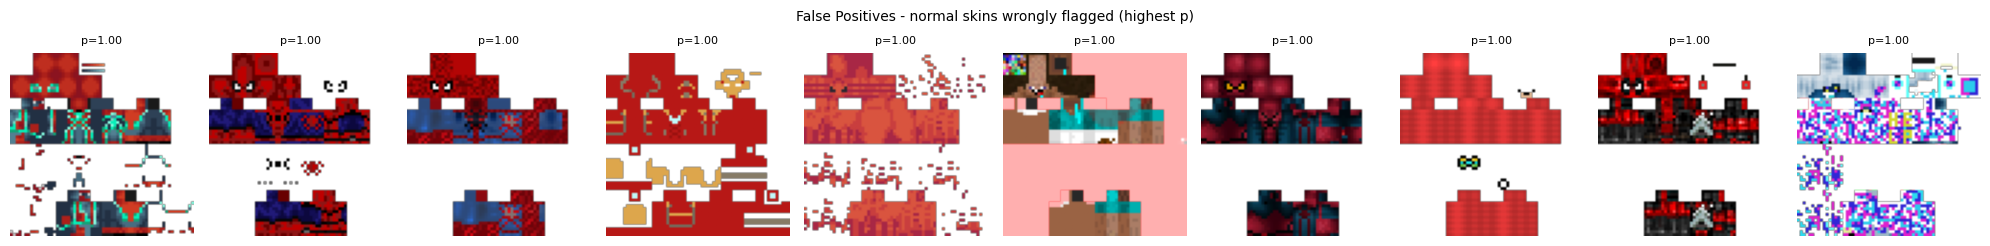

In [133]:
N = 10
y_true = y_test.astype(int)

# worst false negatives: actually flagged, predicted normal, lowest probability first
fn_idx = np.where((y_true == 1) & (y_pred_tuned == 0))[0]
fn_idx = fn_idx[np.argsort(y_prob[fn_idx])][:N]

# worst false positives: actually normal, predicted flagged, highest probability first
fp_idx = np.where((y_true == 0) & (y_pred_tuned == 1))[0]
fp_idx = fp_idx[np.argsort(-y_prob[fp_idx])][:N]

for title, idx in [("False Negatives - missed flagged skins (lowest p)", fn_idx),
                   ("False Positives - normal skins wrongly flagged (highest p)", fp_idx)]:
    if len(idx) == 0:
        print(f"No errors for: {title}")
        continue
    fig, axes = plt.subplots(1, len(idx), figsize=(2 * len(idx), 2.5))
    fig.suptitle(title, fontsize=10)
    for ax, i in zip(np.atleast_1d(axes), idx):
        ax.imshow(X_test[i, :, :, :4])
        ax.set_title(f"p={y_prob[i]:.2f}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

A erlier run with an uncleaned dataset showed us this:
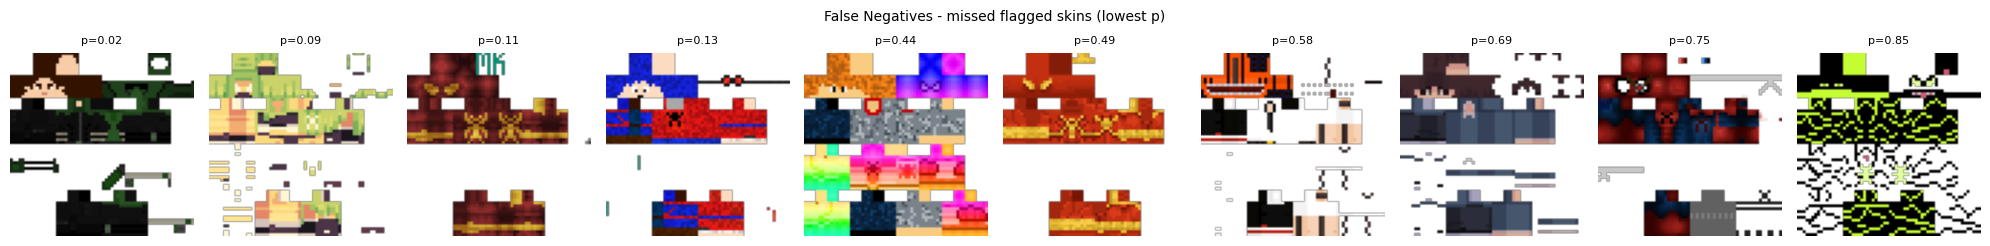
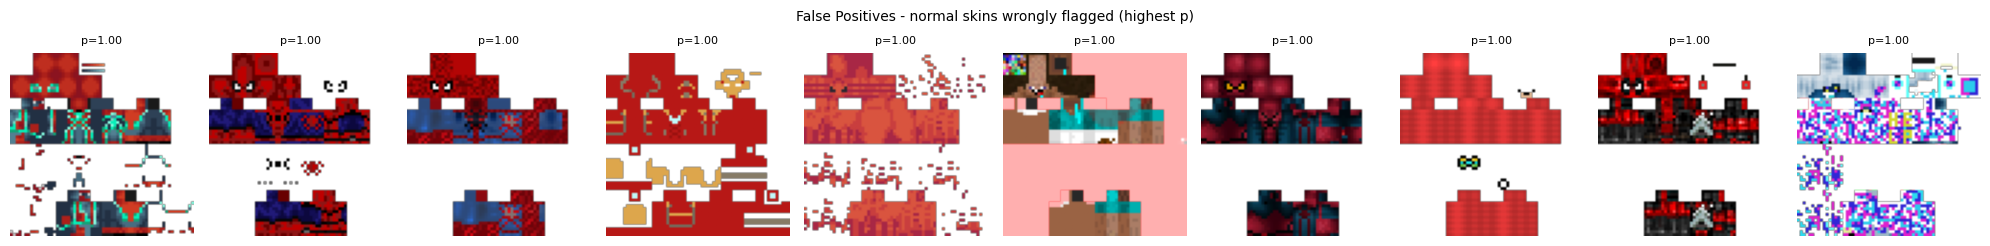
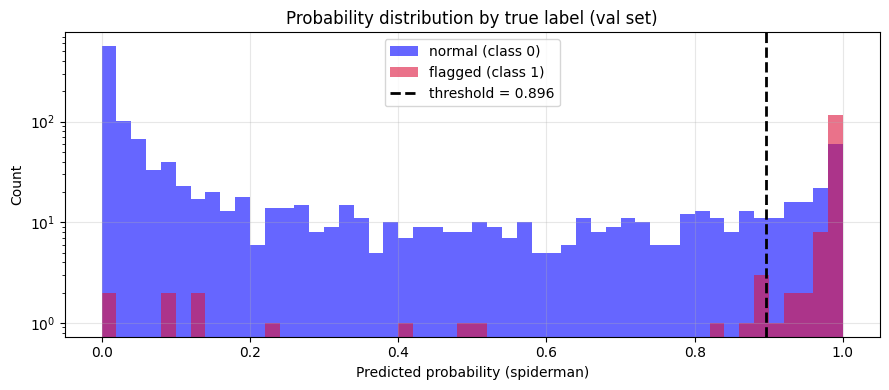
**There were some spidermen inside the normal data set and some non-spidermen inside the spiderman set. Swapping the labels and retraining the model heavily increased model precision!**
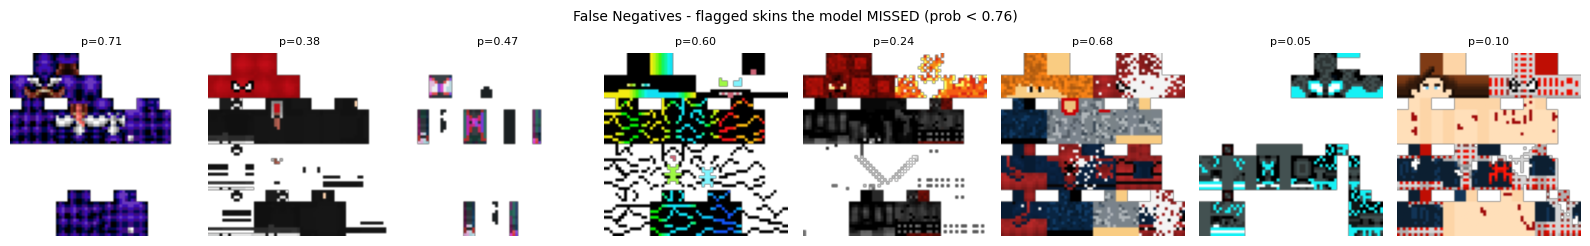
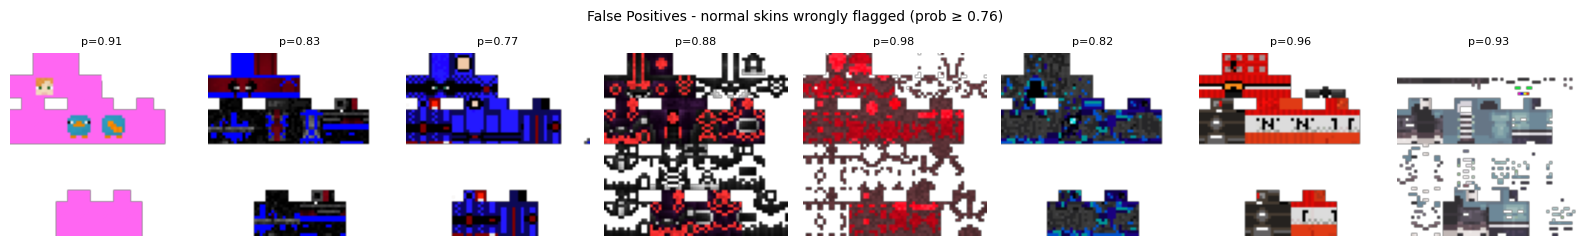

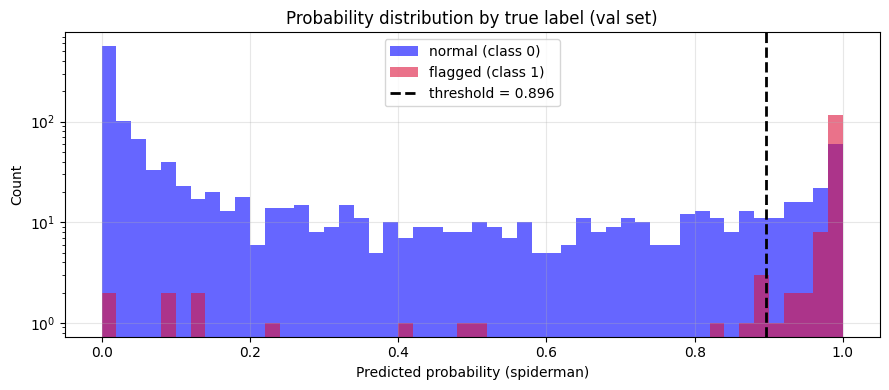

In [134]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(y_prob_val[y_val == 0], bins=50, range=(0, 1),alpha=0.6, label="normal (class 0)", color="blue")
ax.hist(y_prob_val[y_val == 1], bins=50, range=(0, 1),alpha=0.6, label="flagged (class 1)", color="crimson")

ax.axvline(BEST_THRESH, color="black", linestyle="--", linewidth=2, label=f"threshold = {BEST_THRESH:.3f}")

ax.set_xlabel("Predicted probability (spiderman)")
ax.set_ylabel("Count")
ax.set_title("Probability distribution by true label (val set)")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 18. Results Summary & Comparison

We compare all models / thresholds against the majority-class baseline.

# TODO!

---
## 19. Conclusion & Key Learnings

### What we built

A binary CNN classifier for Minecraft skin images (64×64 RGBA) that detects copyrighted/banned character skins with high reliability.

### Key design decisions and why they matter

| Decision | Impact |
|---|---|

### Limitations & future work


In [104]:
# Save the final model
model.save(str(MODEL_PATH) + "_10k_sunday" + ".keras")
print(f"Model saved to: {MODEL_PATH}")

Model saved to: ..\04_Modeling\best_model.keras
